# TP5 : Positionnement Multidimensionnel (MDS)

Importez les bibliothèques suivantes.

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA et la NMF. Le présent TP utilisant les résultats de ces dernier, voici une cellule important les classes `KMeans` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)**), `PCA` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)**) et `NMF` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.NMF.html)**) de la bibliothèque `sklearn`. Regardez bien les documentations. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies. 

In [2]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, NMF

def accuracy(labels):
    ct = pd.crosstab(labels, y)
    row_maxes = ct.max(axis=1)
    sum_of_maxes = row_maxes.sum()
    total_elements = ct.values.sum()
    proportion = sum_of_maxes / total_elements
    return proportion

Nous avons également besoin de la fonction affichant une image ou une liste d'images (au format 784 pixels).

In [3]:
def display_image(source):
    if len(source) == 784:
        images = [source]
    elif len(source[0]) == 784:
        images = source
    else:
        print("error")
    
    l = len(images)
    c = math.ceil(l / 3)
    fig, axes = plt.subplots(c, 3, figsize=(12, 5))

    for i, ax in enumerate(axes.flat):
        if i < l:
            img = images[i].reshape(28, 28)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Image {i + 1}")
        ax.axis('off')

Enfin, importez les jeux de données.

In [4]:
## from google.colab import files
## data_to_load1 = files.upload()
## import io>
## df_pixels = pd.read_csv(io.BytesIO(data_to_load1['pixels.csv']))

df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_label = pd.read_csv("labels.csv")
y = df_label["label"].values

L'objectif de ce TP va commencer par la définition progressive (par Monkey-Patching) d'une classe `MyMDS` implémentant l'algorithme de MDS donné dans la présentation.

In [5]:
class MyMDS:
    def __init__(self, n_components):
        self.n_components = n_components
        
        self.eigenvalues = None
        self.components = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1 

La première étape est de coder une fonction `distances(data)` construisant la matrice de distance d'une matrice de données `data`. Si $X$ est une matrice où chaque ligne est une donnée, la matrice $D$ de distances de $X$ est telles que $D_{ij} = d(X[i],X[j])$ pour tous $i,j$. Il serait par exemple possible d'utiliser la formule suivante :

- `np.linalg.norm(data.reshape((data.shape[0],1,data.shape[1])) - data.reshape((1,data.shape[0],data.shape[1]),axis=2)`

Néanmoins, si la matrice de données a 2535 lignes et 784 colonnes, la matrice intermédiaire utilisée dans ce calcul a $2535^2 \times 784$ entrées. Cela fait plus de 5 milliards. Cela rend le calcul infaisable (pour des raisons d'attribution de mémoire). 

Pour cette raison, il convient d'utiliser la formule d'Al-Kashi :
$$d(x,y)^2 = ||x||^2 + ||y||^2 - 2 \langle x,y \rangle$$

(Note : Il se peut que des erreurs d'approximation résultent en de minuscules nombres négatifs au lieu de 0. Cela empêche l'utilisation de la fonction `np.sqrt`. Il convient alors de remplacer ces erreurs négatives par des 0.)

In [6]:
def distances(data):
    gram = np.dot(data,data.T)
    l_norme= np.sum(data**2,axis=1)
    l_dist= l_norme[:,np.newaxis] + l_norme[np.newaxis,:] - 2*gram
    l_dist = np.maximum(l_dist,0)
    l_dist_1= np.sqrt(l_dist)
    return l_dist_1

## Exercice 2

Il s'agit maintenant de construire les fonctions qui formeront le corps de la classe `MDS`.

1. Construisez une fonction `double_centre(D)` qui reconstruit la matrice de Gram à partir d'une matrice de distances. 

In [7]:
def double_centre(D):
    n = D.shape[0]
    J = np.eye(n)- (1/n)* np.ones((n,n))
    D_car= D**2
    B= -0.5 *(J @ D_car @ J)
    return B

2. On opère ensuite une décomposition spectrale pour récupérer les valeurs propres et ses vecteurs propres de la matrice de Gram. On peut ensuite choisir les $n$ composantes les plus importantes. Construisez une fonction `get_principal_components(comatrix, n_components)` qui renvoie une liste `top_eigenvalues, top_eigenvectors, total` où :

- `top_eigenvalues` est le vecteur de $n$ plus granges valeurs propres ordonnées de la plus petite à la plus grande,
- `top_eigenvectors` est la matrice où chacune des $n$ colonnes correspond à un vecteur propre et où ils sont ordonnés dans l'ordre correspondant à leurs valeurs propres respectives.

Attention à l'ordre et aux dimensions de vos objets ! Utilisez la fonction `np.linalg.eigh` (**[documentation](https://numpy.org/doc/2.1/reference/generated/numpy.linalg.eigh.html#numpy.linalg.eigh)**).

In [8]:
def get_principal_components(comatrix,n_components):
    eigenvalues, eigenvectors = np.linalg.eigh(comatrix)  #elle sont trié je pense par defaut du plus petit au plus grand deja
    top_eigenvalues = eigenvalues[-n_components:]
    top_eigenvectors = eigenvectors[:, -n_components:]
    # total = np.sum(eignvalues)
    return top_eigenvalues, top_eigenvectors
     

## Exercice 3

Nous allons maintenant construire la classe par Monkey-Patching.

1. Construisez une fonction `fit_transform(self, data)` implémentant la totalité de l'algorithme du MDS à l'aide des fonctions précedemments définies. Cette fonction renvoie la matrice projetée et assigne `self.eigenvalues` et `self.components` (au format où chaque ligne est une composante).

In [9]:
def fit_transform(self, data):
    d = distances(data)
    b = double_centre(d)
    eigenvalues, eigenvectors = get_principal_components(b, self.n_components)
    self.eigenvalues = eigenvalues
    self.components = eigenvectors.T  # chaque ligne = une composante
    eigenvalues_racine = np.sqrt(np.maximum(eigenvalues, 0))
    proj_data = eigenvectors * eigenvalues_racine
    return proj_data

MyMDS.fit_transform = fit_transform

2. Vérifiez que la classe est bien implémentée en réalisant une MDS sur $X$ avec deux composantes. Visualisez le résultat dans un nuage de points avec `plt.scatter` (**[documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html#matplotlib.pyplot.scatter)**) coloré par nos labels (`y`). Faites la même chose avec une PCA à deux composantes. Les résultats devraient être les mêmes (à une rotation près). 

Text(0, 0.5, 'C 2')

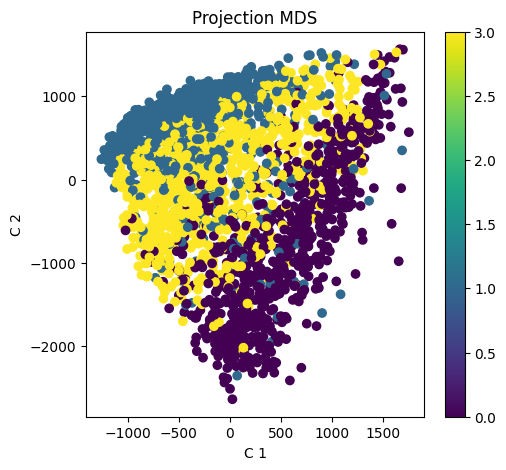

In [10]:
mds = MyMDS(n_components=2)
X_mds = mds.fit_transform(X) 
# Visualisation MDS
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=y)
plt.colorbar()
plt.title("Projection MDS")
plt.xlabel("C 1")
plt.ylabel("C 2")


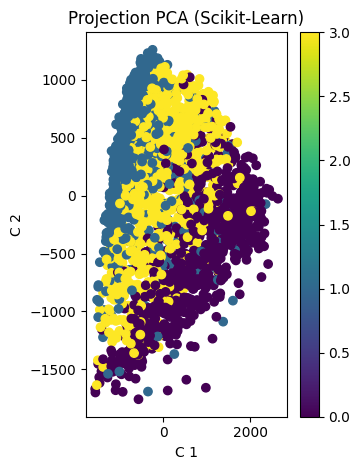

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
# Visualisation PCA
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y)
plt.colorbar()
plt.title("Projection PCA (Scikit-Learn)")
plt.xlabel("C 1")
plt.ylabel("C 2")

plt.tight_layout()
plt.show()

## Exercice 4

Nous allons maintenant construire une classe `MyIsomap` implémentant l'algorithme Isomap présenté dans la présentation. Il va falloir faire une MDS sur une matrice de distances géodésiques approximées. Construisez la fonction `fit_transform(self, data)` qui retourne la matrice projetée après application de l'algorithme.

Utilisez la fonction `kneighbors_graph` (**[documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.kneighbors_graph.html)**) pour construire la matrice des distances des $k$ voisins les plus proches. Utilisez la fonction `shortest_path` (**[documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.csgraph.shortest_path.html)**) pour implémenter l'algorithme de Djikstra.

In [12]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path

class MyIsomap:
    def __init__(self, n_neighbors, n_components):
        self.n_neighbors = n_neighbors
        self.n_components = n_components
        self.mds = MyMDS(n_components) 
        
    def fit_transform(self, X):
        graph = kneighbors_graph(X,self.n_neighbors,mode='distance',include_self=False)
        geo_distances= shortest_path(graph,method='D',directed=False)
        b = double_centre(geo_distances)
        eigenvalues,eigenvectors = get_principal_components(b,self.n_components)
        racine_eignvls= np.sqrt(np.maximum(eigenvalues,0))
        proj_data = eigenvectors*racine_eignvls
        return proj_data
    
    

## Exercice 5

1. Appliquez Isomap (deux composantes) à nos données et visualisez les résultats dans un nuage de points colorés par nos labels. Que se passe t-il lorsque l'on fait varier le nombre de voisins ?

Calcul de l'Isomap (k=30)...


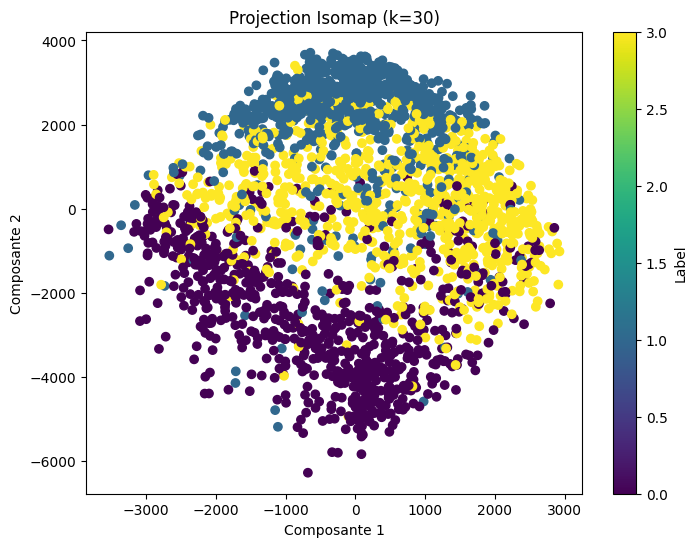

Calcul pour k=5...
Calcul pour k=15...
Calcul pour k=30...
Calcul pour k=80...


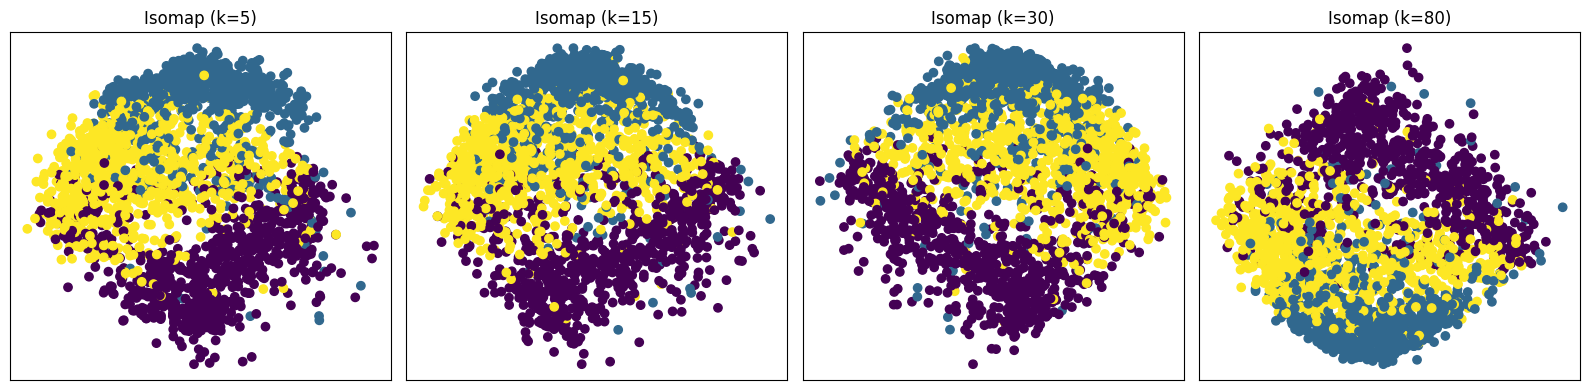

In [13]:
import matplotlib.pyplot as plt
print("Calcul de l'Isomap (k=30)...")
isomap = MyIsomap(n_neighbors=30, n_components=2)
X_isomap = isomap.fit_transform(X)  

plt.figure(figsize=(8, 6))
plt.scatter(X_isomap[:, 0], X_isomap[:, 1], c=y)
plt.colorbar(label='Label')
plt.title("Projection Isomap (k=30)")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.show()

k_values = [5, 15, 30, 80]

plt.figure(figsize=(16, 4))

for i, k in enumerate(k_values):
    print(f"Calcul pour k={k}...")
    iso = MyIsomap(n_neighbors=k, n_components=2)
    X_k = iso.fit_transform(X)
    
    plt.subplot(1, 4, i+1)
    plt.scatter(X_k[:, 0], X_k[:, 1], c=y)
    plt.title(f"Isomap (k={k})")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

Si $k$ est trop petit : Le nuage est éclaté en plein de petits morceaux isolés, on perd la continuité.Si $k$ est trop grand : L'algo crée des "raccourcis" entre des points éloignés. Tout se mélange et la structure s'écrase.Conclusion : Il faut un juste milieu (vers 10-20 voisins) pour que la forme se déplie correctement et que les groupes de chiffres apparaissent nettement

2. Changez la couleur des points pour qu'ils soient colorés en fonction de leur classification par un K-clustering de la projection Isomap de `X` en 2 dimensions, avec 3 clusters. Affichez la précision de ces labels. Pour quel nombre de voisins trouve t-on les meilleurs résultats ? Pourquoi ?

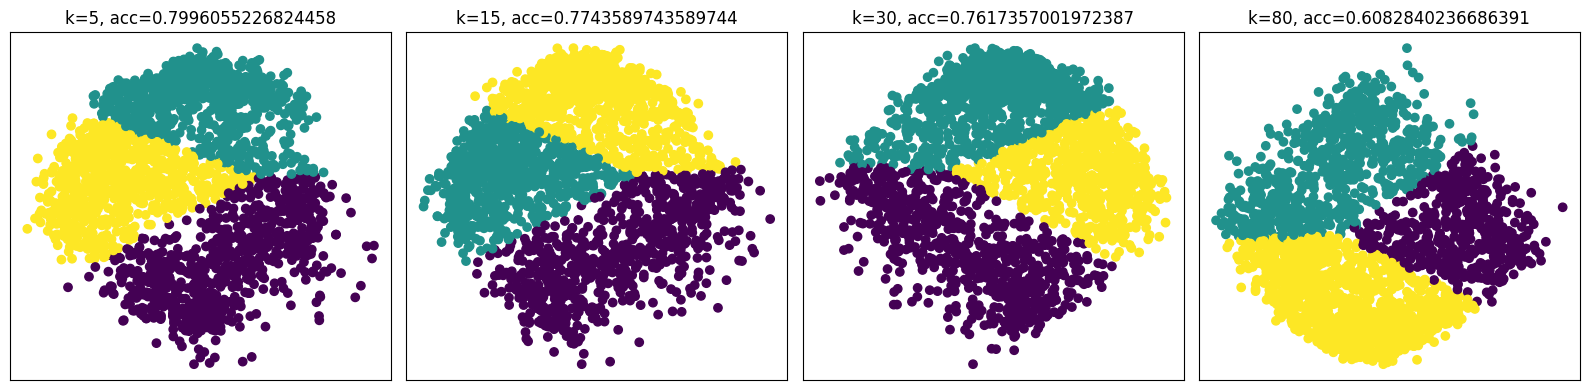

Meilleure précision: 0.7996055226824458 pour k=5


In [14]:
k_values = [5, 15, 30, 80]
best_k, best_acc = None, -1

plt.figure(figsize=(16, 4))

for i, k in enumerate(k_values):
    iso = MyIsomap(n_neighbors=k, n_components=2)
    X_k = iso.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X_k)
    acc = accuracy(labels)

    if acc>best_acc:
        best_acc, best_k = acc, k

    plt.subplot(1, 4, i + 1)
    plt.scatter(X_k[:, 0], X_k[:, 1], c=labels)
    plt.title(f"k={k}, acc={acc}")
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

print(f"Meilleure précision: {best_acc} pour k={best_k}")

d'après les résultats affichés, on obtient la meilleure précision (0.800) avec le plus petit nombre de voisins testé, soit k = 5. On observe que plus on augmente $k$, plus la précision diminue (elle tombe à 0.608 pour k=80).Cela s'explique par le fonctionnement d'Isomap :Avec un petit k (5) : L'algorithme reste "local". Il ne connecte que les points très proches, ce qui permet de bien suivre la courbure de la variété (la forme des données) et de la "déplier" correctement. Les clusters restent donc bien séparés.Avec un grand k (80) : On crée des "courts-circuits". Le graphe commence à connecter des points qui sont proches géographiquement (distance euclidienne) mais qui sont en réalité très loin sur la structure des données (par exemple, deux parties opposées d'une boucle). Cela "écrase" la projection qui ressemble alors de plus en plus à une simple PCA linéaire, mélangeant ainsi les classes.

## Exercice 5

On peut utiliser Isomap pour mieux visualiser la manière dont la NMF peut séparer les données. 

1. Réalisez une NMF sur $X$ avec 8 composantes. Utilisez la classe de `sklearn` avec la méthode d'initialisation `nndsvd` (pour de meilleurs résultats de convergence). Faites tourner un $3-$clustering sur la matrice projetée et affichez sa précision.

In [15]:
nmf = NMF(n_components=8, init="nndsvd", random_state=0)
X_nmf = nmf.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels_nmf = kmeans.fit_predict(X_nmf)

acc_nmf = accuracy(labels_nmf)
print(f"Précision NMF + KMeans (3 clusters): {acc_nmf}")

Précision NMF + KMeans (3 clusters): 0.8863905325443787


C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


2. Le résultat devrait être assez satisfaisant. Nous voulons maintenant visualisez la manière dont la séparation des données s'opére dans la NMF. Essayons d'abord de projeter en deux dimensions avec une méthode linéaire (PCA ou MDS). Visualisez le résultat avec un nuage de points colorés par nos labels `y`.

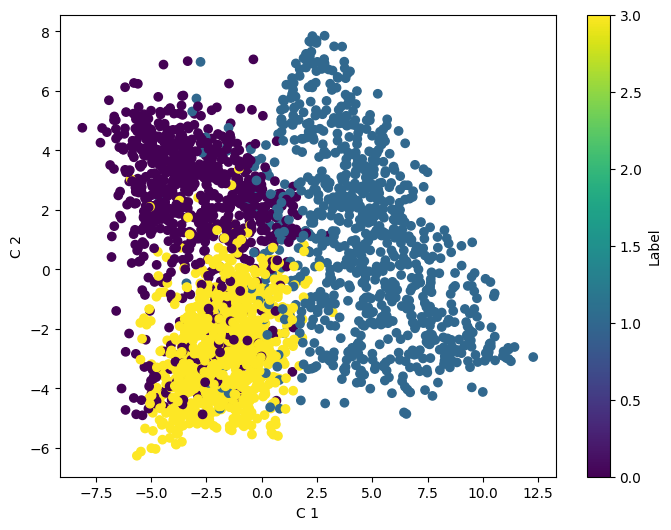

In [16]:
pca_nmf = PCA(n_components=2)
X_nmf_pca = pca_nmf.fit_transform(X_nmf)

plt.figure(figsize=(8, 6))
plt.scatter(X_nmf_pca[:, 0], X_nmf_pca[:, 1], c=y)
plt.colorbar(label="Label")
plt.xlabel("C 1")
plt.ylabel("C 2")
plt.show()

3. Faites la même chose avec Isomap avec 10 voisins.

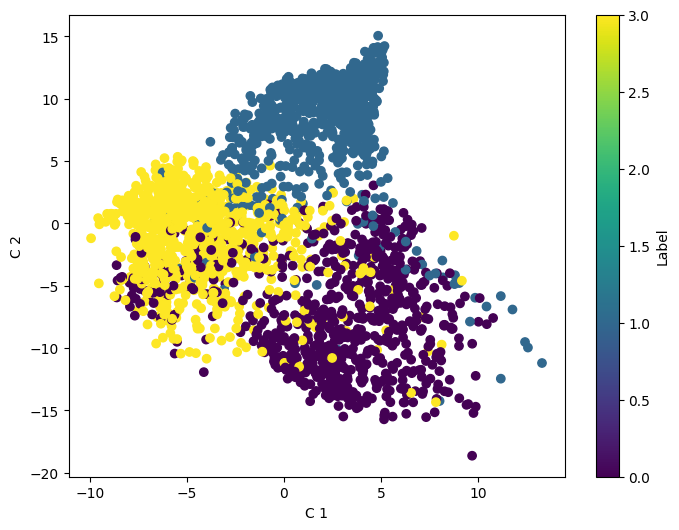

In [17]:
isomap_nmf = MyIsomap(n_neighbors=10, n_components=2)
X_nmf_isomap = isomap_nmf.fit_transform(X_nmf)

plt.figure(figsize=(8, 6))
plt.scatter(X_nmf_isomap[:, 0], X_nmf_isomap[:, 1], c=y)
plt.colorbar(label="Label")
plt.xlabel("C 1")
plt.ylabel("C 2")
plt.show()

4. Faites varier le nombres de composantes de la NMF et le nombre de voisins dans l'Isomap. Interprétez les résultats.

C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(
C:\Users\TRETEC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 500 reached. Increase it to improve convergence.
  warnings.warn(


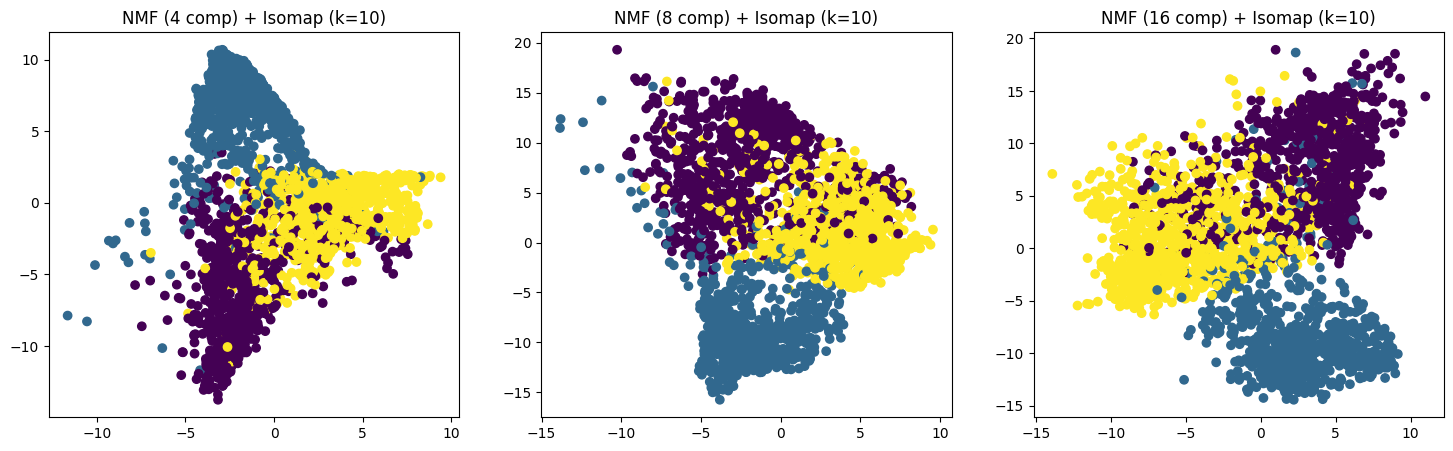

In [18]:
n_composantes_liste = [4, 8, 16]
voisins = 10

plt.figure(figsize=(18, 5))

for i, n_comp in enumerate(n_composantes_liste):
    nmf_temp = NMF(n_components=n_comp, init="nndsvd", random_state=0, max_iter=500)
    X_nmf_temp = nmf_temp.fit_transform(X)

    iso_temp = MyIsomap(n_neighbors=voisins, n_components=2)
    X_proj = iso_temp.fit_transform(X_nmf_temp)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_proj[:, 0], X_proj[:, 1], c=y)
    plt.title(f"NMF ({n_comp} comp) + Isomap (k={voisins})")

plt.show()

On constate que l'augmentation du nombre de composantes de la NMF permet de nettement mieux séparer les chiffres en capturant des détails plus fins, mais il est indispensable de coupler cela avec un nombre de voisins modéré dans l'Isomap pour bien déplier cette nouvelle structure sans créer de raccourcis géométriques qui finiraient par écraser les clusters les uns sur les autres